# Deconvolution 학습 (U-Net)

Conventional method인 **PSF(point spread function) 3종과 Wiener filter** 를 **UNet based model**과 비교한다. `


In [1]:
# Run this codeblock to mount your Google Drive in Google Colab.
from google.colab import drive

drive.mount("/content/drive/")

Mounted at /content/drive/


In [2]:
# loguru 는 Colab 기본 이미지에 없으므로 필요할 때만 설치
try:
    import loguru  # noqa: F401
except ImportError:
    !pip install -q loguru

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.9 MB/s eta 0:00:00


## 1. PSF 예시

Deconvolution: **측정 = 원본 * PSF**

PSF 3종으로 직접 blur 를 만들어 **Wiener filter** 를 적용해본다.

| PSF | 정의 | 특징 |
|---|---|---|
| Gaussian blur | 등방성 gaussian kernel | 고주파가 지수적으로 죽는다. spectrum 에 0 이 없다 |
| Motion blur | 대각선으로 길게 늘어진 gaussian (`Lecture_5_key.ipynb`) | 한 방향으로만 심하게 뭉개진다 |
| Dipole forward model | `common/dipole.py` 의 dipole kernel | k-space 에서 **magic angle (약 54.7도) 원뿔에서 0** → 그 성분은 복원 불가. 뒤에서 U-Net 이 배울 forward model |

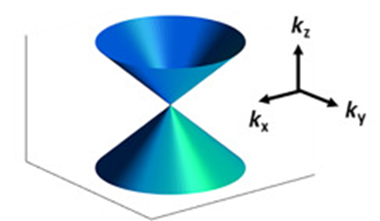

Loaded sample image: L1_00fa35a6f61da36f1c9b79cefd23baea.npy
Shape: (256, 256) | Range: [0.000, 1.000]


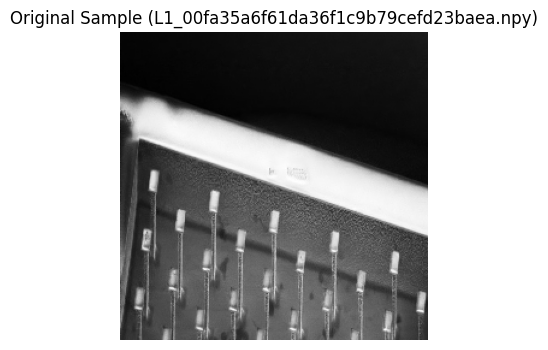

In [3]:
import glob
import json
import os
import random
import time
import warnings
from collections.abc import Callable
from dataclasses import asdict, dataclass, field
from datetime import datetime
from enum import Enum, IntEnum
from functools import lru_cache
from pathlib import Path
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from scipy.io import savemat
from torch import Tensor, nn
from torch.nn import functional
from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

ROOT = Path("/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습")
if not ROOT.exists():
    # Fallback to local workspace if not on Colab Drive
    _local_root = Path.cwd()
    if (_local_root / "ref/dataset").exists():
        ROOT = _local_root / "ref"
    elif (_local_root / "dataset").exists():
        ROOT = _local_root

DATA_ROOT = ROOT / "dataset"

# PSF 예시에 쓸 영상을 train dataset 또는 test_label에서 한 장 가져온다.
train_files = sorted(glob.glob(str(DATA_ROOT / "train/*.npy")))
if not train_files:
    train_files = sorted(glob.glob(str(DATA_ROOT / "test_label/*.npy")))

if train_files:
    idx = min(10, len(train_files) - 1)
    _img = np.load(train_files[idx]).astype(np.float64)
    if _img.ndim == 3:
        _img = _img.squeeze()
    _img = (_img - _img.min()) / (_img.max() - _img.min() + 1e-8)
    example = _img[: _img.shape[0] // 2 * 2, : _img.shape[1] // 2 * 2]
    img_name = Path(train_files[idx]).name
else:
    # Fallback sample pattern (256x256) if dataset is not yet downloaded
    y, x = np.mgrid[:256, :256]
    example = np.sin(x / 10.0) * np.cos(y / 10.0) * 0.5 + 0.5
    img_name = "synthetic_sample.npy"

# 'bird' 변수명 호환성 유지
bird = example

print(f"Loaded sample image: {img_name}")
print(f"Shape: {example.shape} | Range: [{example.min():.3f}, {example.max():.3f}]")

plt.figure(figsize=(5, 4))
plt.imshow(example, cmap="gray", vmin=0.0, vmax=1.0)
plt.title(f"Original Sample ({img_name})")
plt.axis("off")
plt.show()


## 1-1. PSF

In [4]:
def pad_psf_to_image(
    psf: np.ndarray,
    shape: tuple[int, int],
) -> np.ndarray:
    """kernel 을 영상 크기로 zero-pad (Lecture_5_key.ipynb 와 동일한 중앙 정렬)."""
    padded = np.zeros(shape, dtype=np.float64)
    a, b = shape
    c, d = psf.shape
    for i in range(c):
        for j in range(d):
            padded[
                int(np.floor(a / 2) - np.floor(c / 2) + i),
                int(np.floor(b / 2) - np.floor(d / 2) + j),
            ] = psf[i, j]
    return padded


def psf_to_otf(
    psf: np.ndarray,
    shape: tuple[int, int],
) -> np.ndarray:
    """중앙 정렬 PSF -> OTF H(u,v). ifftshift 로 kernel 중심을 원점으로 옮겨 zero-phase 로 만든다."""
    return np.fft.fft2(np.fft.ifftshift(pad_psf_to_image(psf, shape)))


def apply_otf(
    img: np.ndarray,
    otf: np.ndarray,
) -> np.ndarray:
    """measure = ifft2(fft2(img) * H). 공간 영역 convolution 과 같다 (circular)."""
    return np.real(np.fft.ifft2(np.fft.fft2(img) * otf))


def gaussian_psf(
    size: int = 21,
    sigma: float = 3.0,
) -> np.ndarray:
    """등방성 gaussian PSF."""
    ax = np.arange(size) - size // 2
    xx, yy = np.meshgrid(ax, ax, indexing="ij")
    psf = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return psf / psf.sum()


def motion_blur_psf(
    size: int = 41,
    sigma_along: float = 12.0,
    sigma_across: float = 1.0,
) -> np.ndarray:
    """Lecture_5_key.ipynb 의 대각선 motion blur kernel.

    (+1, +1) 방향으로 길게 늘어진 gaussian. gaussian 이라 spectrum 에 zero 가 없어
    Wiener 가 안정적으로 복원할 수 있다.
    """
    kernel = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            di = i - size // 2
            dj = j - size // 2
            along = (di + dj) / np.sqrt(2)
            across = (-di + dj) / np.sqrt(2)
            kernel[i, j] = np.exp(-(along**2) / (2 * sigma_along**2) - across**2 / (2 * sigma_across**2))
    return kernel / kernel.sum()


@lru_cache(maxsize=16)
def dipole_kernel(
    matrix_size: tuple[int, int],
    voxel_size: tuple[float, float] = (1.0, 1.0),
    B0_dir: tuple[float, float] = (0.0, 1.0),
) -> torch.Tensor:
    """common/dipole.py 원본. fftshift 가 들어 있어 반환값이 곧 OTF 다."""
    y = np.arange(-matrix_size[1] / 2, matrix_size[1] / 2, 1)
    x = np.arange(-matrix_size[0] / 2, matrix_size[0] / 2, 1)
    Y, X = np.meshgrid(y, x)

    X = X / (matrix_size[0] * voxel_size[0])
    Y = Y / (matrix_size[1] * voxel_size[1])

    D = 1 / 3 - (X * B0_dir[0] + Y * B0_dir[1]) ** 2 / (X**2 + Y**2 + 1e-8)
    D = np.fft.fftshift(D)
    D = torch.tensor(D, dtype=torch.float32)
    return D


# PSF 3종. K 는 Wiener filter 의 tunable parameter (아래 1-3 참고)
DEMO_NOISE_STD: float = 0.0  # blur 후 더할 gaussian noise 표준편차. 0 보다 크면 K 를 키워야 한다

PSF_SPECS: list[dict] = [
    {
        "key": "gaussian",
        "label": "Gaussian blur\n21x21, sigma=3",
        "psf": gaussian_psf(size=21, sigma=3.0),
        "K": 1e-6,
        "signed": False,
    },
    {
        "key": "motion",
        "label": "Motion blur (diagonal)\n41x41, sigma 12 / 1",
        "psf": motion_blur_psf(size=41, sigma_along=12.0, sigma_across=1.0),
        "K": 1e-6,
        "signed": False,
    },
    {
        "key": "dipole",
        "label": "Dipole forward model\ncommon/dipole.py",
        "psf": None,  # 공간 kernel 없이 OTF 를 직접 만든다
        "K": 1e-4,
        "signed": True,  # 결과가 음수도 가지므로 표시 스케일을 따로 잡는다
    },
]

target_sample = bird if "bird" in globals() else example
for spec in PSF_SPECS:
    if spec["psf"] is None:
        spec["otf"] = dipole_kernel(matrix_size=target_sample.shape).numpy().astype(np.float64)
    else:
        spec["otf"] = psf_to_otf(spec["psf"], target_sample.shape)
    _h = np.abs(spec["otf"])
    print(f"{spec['key']:<10} |H| min {_h.min():.2e}  max {_h.max():.3f}")

gaussian   |H| min 1.56e-11  max 1.000
motion     |H| min 1.63e-07  max 1.000
dipole     |H| min 2.27e-05  max 0.667


### 1-2. PSNR / SSIM


In [5]:
IMG_DIM: int = 4


class SSIMcal(torch.nn.Module):
    def __init__(
        self,
        win_size: int = 11,
        k1: float = 0.01,
        k2: float = 0.03,
    ):
        super().__init__()
        self.win_size = win_size
        self.k1, self.k2 = k1, k2
        self.register_buffer("w", torch.ones(1, 1, win_size, win_size) / win_size**2)
        np_ = win_size**2
        self.cov_norm = np_ / (np_ - 1)

    def forward(
        self,
        img: torch.Tensor,
        ref: torch.Tensor,
        data_range: torch.Tensor,
    ) -> torch.Tensor:
        data_range = data_range[:, None, None, None]
        C1 = (self.k1 * data_range) ** 2
        C2 = (self.k2 * data_range) ** 2

        w = self.w.to(img.device)
        ux = functional.conv2d(img, w)
        uy = functional.conv2d(ref, w)
        uxx = functional.conv2d(img * img, w)
        uyy = functional.conv2d(ref * ref, w)
        uxy = functional.conv2d(img * ref, w)

        vx = self.cov_norm * (uxx - ux * ux)
        vy = self.cov_norm * (uyy - uy * uy)
        vxy = self.cov_norm * (uxy - ux * uy)

        A1 = 2 * ux * uy + C1
        A2 = 2 * vxy + C2
        B1 = ux**2 + uy**2 + C1
        B2 = vx + vy + C2

        S = (A1 * A2) / (B1 * B2)
        return torch.mean(S, dim=[2, 3], keepdim=True)


ssim_cal = SSIMcal()


def calculate_ssim(
    img: torch.Tensor,
    ref: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> torch.Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is None:
        img_mask, ref_mask = img, ref
    else:
        if mask.dim() != IMG_DIM:
            raise ValueError("Mask must be 4D.")
        img_mask, ref_mask = img * mask, ref * mask

    ones = torch.ones(ref.shape[0], device=ref.device)
    return ssim_cal.forward(img_mask, ref_mask, ones)


def calculate_psnr(
    img: torch.Tensor,
    ref: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> torch.Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is not None:
        if mask.dim() != IMG_DIM:
            raise ValueError("Mask must be 4D.")
        img_mask, ref_mask = img * mask, ref * mask
        mse = torch.sum((img_mask - ref_mask) ** 2, dim=(1, 2, 3), keepdim=True) / torch.sum(
            mask, dim=(1, 2, 3), keepdim=True
        )
    else:
        mse = torch.mean(functional.mse_loss(img, ref, reduction="none"), dim=(1, 2, 3), keepdim=True)

    img_max = torch.amax(ref, dim=(1, 2, 3), keepdim=True)
    return 10 * torch.log10(img_max**2 / (mse + 1e-12))


def psnr_ssim(
    img: np.ndarray,
    ref: np.ndarray,
) -> tuple[float, float]:
    """2차원 numpy 영상 -> (PSNR, SSIM). 위 함수들과 완전히 같은 계산이다."""

    def _t(arr: np.ndarray) -> torch.Tensor:
        return torch.from_numpy(np.ascontiguousarray(arr)).float()[None, None]

    _img, _ref = _t(img), _t(ref)
    return float(calculate_psnr(_img, _ref).item()), float(calculate_ssim(_img, _ref).mean().item())

### 1-3. Wiener filter

$$\bar I = \dfrac{1}{H}\cdot\dfrac{|H|^2}{|H|^2 + K}\hat I$$

`K`: tunable parameter

- `K = 0` 이면 순수 inverse filter (`1/H`). `H` 가 0 에 가까운 주파수에서 노이즈/수치오차가 폭발한다.
- `K` 를 키우면 `|H|^2 << K` 인 주파수를 `H/K` 로 **감쇠**시켜 폭발을 막는다. 대신 그만큼 흐려진다.
- 노이즈가 크면 `K` 도 키운다 (대략 noise 분산 / signal 분산 스케일).


In [6]:
def wiener_filter(
    measure: np.ndarray,
    otf: np.ndarray,
    K: float,
) -> np.ndarray:
    """Wiener filter: (1/H) * |H|^2 / (|H|^2 + K)."""
    h2 = np.abs(otf) ** 2
    safe_den = np.where(np.abs(otf) < 1e-12, 1e-12, otf)  # 0 나눗셈 방지
    w = (1.0 / safe_den) * (h2 / (h2 + K))
    return np.real(np.fft.ifft2(w * np.fft.fft2(measure)))


def tkd_filter(
    measure: np.ndarray,
    otf: np.ndarray,
    clip: float,
) -> np.ndarray:
    """TKD (truncated kernel division): |1/H| 를 clip 으로 제한한다.

    OTF 가 복소수(gaussian/motion blur)면 실수처럼 np.clip 을 걸 수 없다.
    np.clip 은 복소수를 실수부 우선으로 비교하므로 잘린 주파수의 **위상이 날아간다**.
    크기만 clip 하고 위상은 유지해야 한다.
    """
    safe_den = np.where(np.abs(otf) < 1e-12, 1e-12, otf)
    inv = 1.0 / safe_den
    scale = np.minimum(1.0, clip / np.maximum(np.abs(inv), 1e-12))
    return np.real(np.fft.ifft2((inv * scale) * np.fft.fft2(measure)))

### 1-4. Wiener filter


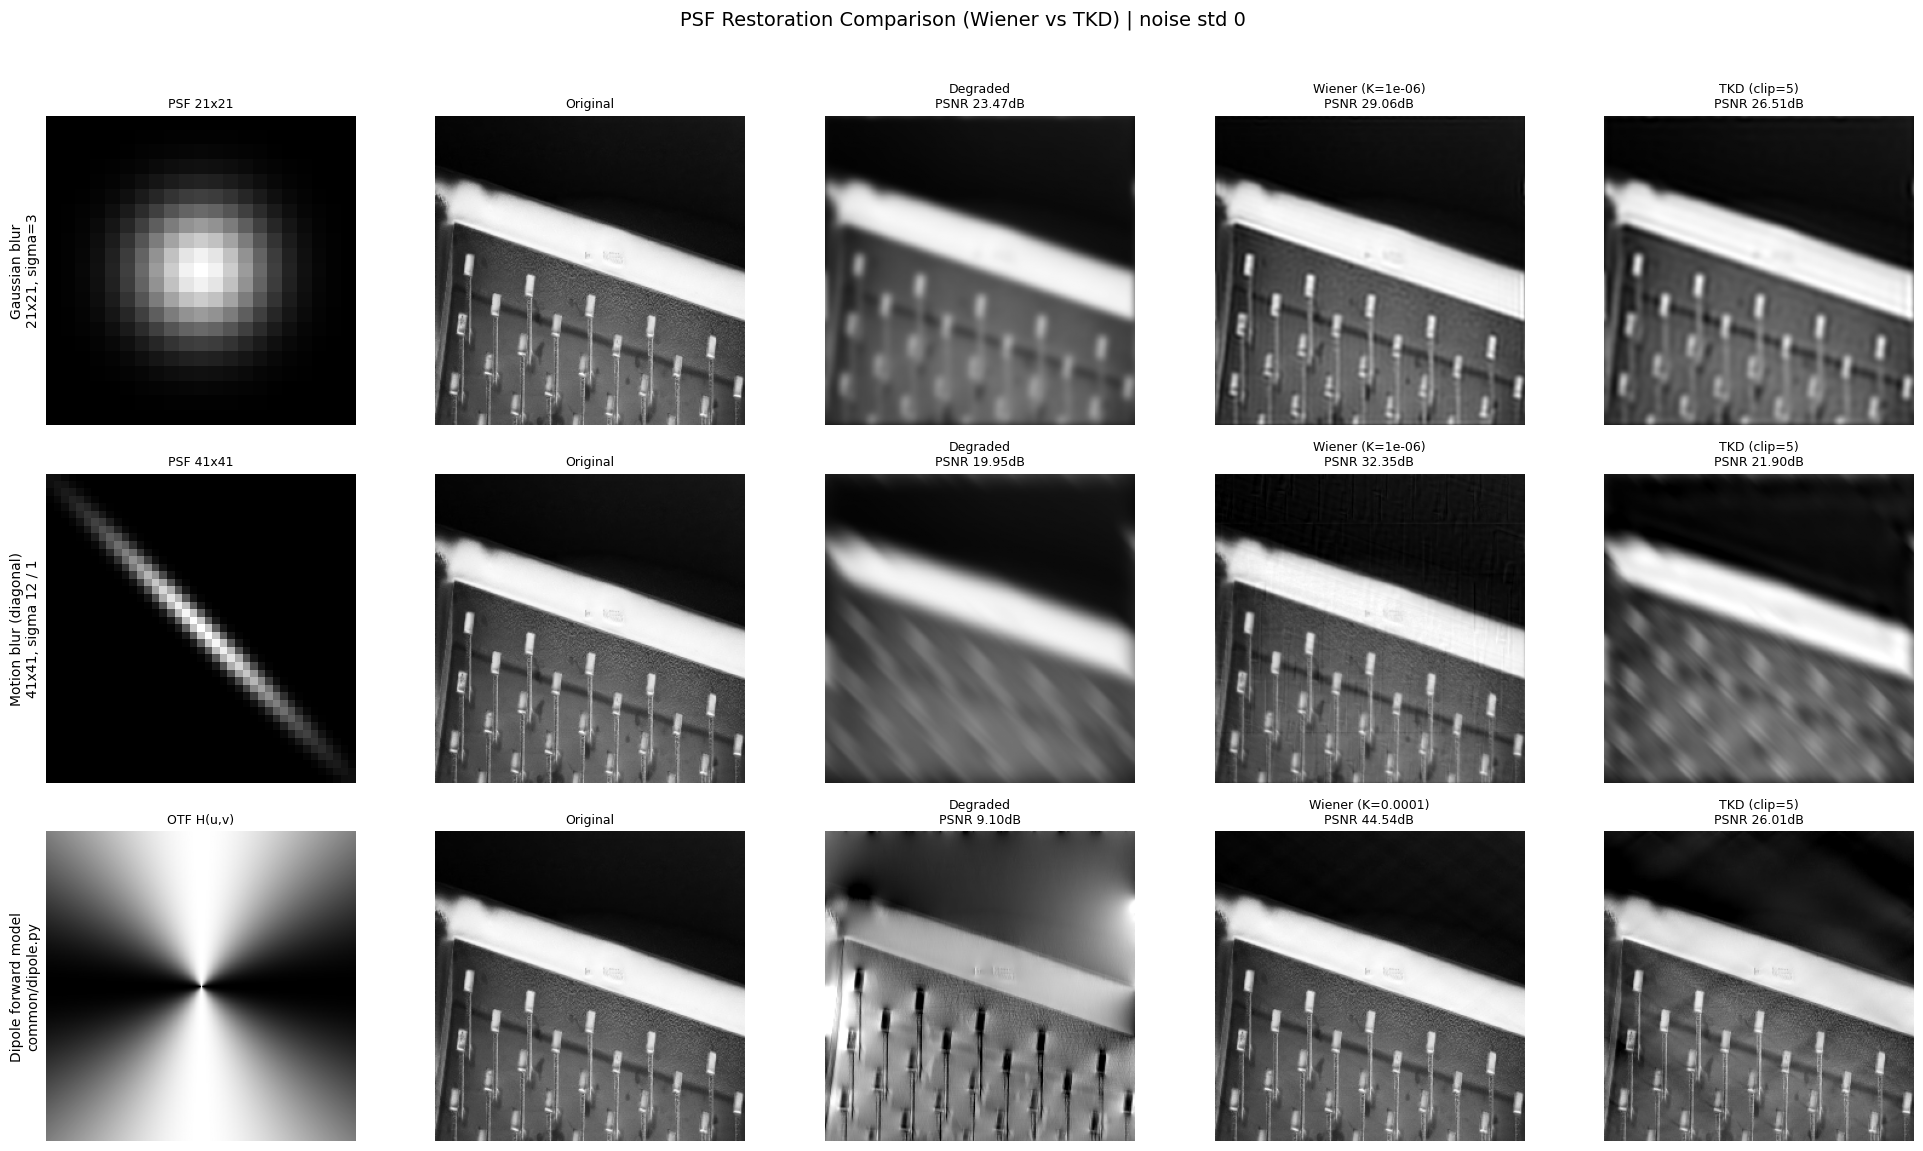

In [7]:
target_sample = bird if isinstance(globals().get("bird"), np.ndarray) else example
rng = np.random.default_rng(0)
rows: list[dict] = []

# 0열(PSF)은 정사각형이라 그냥 두면 다른 패널보다 세로로 커진다.
# 패널 수를 4개에서 5개로 늘리고 width_ratios를 조정합니다.
_aspect = target_sample.shape[0] / target_sample.shape[1]
fig, axes = plt.subplots(
    len(PSF_SPECS),
    5,
    figsize=(20, 3.9 * len(PSF_SPECS)),
    gridspec_kw={"width_ratios": [_aspect, 1, 1, 1, 1]},
)
axes = np.asarray(axes).reshape(len(PSF_SPECS), 5)

# TKD를 위한 clip 값 설정
TKD_CLIP_VAL = 5.0

for r, spec in enumerate(PSF_SPECS):
    otf = spec["otf"]

    # 1) blur (+ 선택적 노이즈)
    measure = apply_otf(target_sample, otf)
    if DEMO_NOISE_STD > 0:
        measure = measure + rng.normal(0.0, DEMO_NOISE_STD, measure.shape)

    # 2) Wiener 복원
    restored_wiener = np.clip(wiener_filter(measure, otf, K=spec["K"]), 0.0, 1.0)

    # 3) TKD 복원 (복소 OTF 는 크기만 자르고 위상은 보존한다)
    restored_tkd = np.clip(tkd_filter(measure, otf, clip=TKD_CLIP_VAL), 0.0, 1.0)

    psnr_deg, ssim_deg = psnr_ssim(measure, target_sample)
    psnr_wie, ssim_wie = psnr_ssim(restored_wiener, target_sample)
    psnr_tkd, ssim_tkd = psnr_ssim(restored_tkd, target_sample)

    rows.append({
        "psf": spec["key"],
        "psnr_degraded": psnr_deg,
        "psnr_wiener": psnr_wie,
        "psnr_tkd": psnr_tkd,
    })

    if spec["signed"]:
        deg_lo, deg_hi = float(np.percentile(measure, 1)), float(np.percentile(measure, 99))
    else:
        deg_lo, deg_hi = 0.0, 1.0

    if spec["psf"] is None:
        kernel_img = np.fft.fftshift(np.real(otf))
        kernel_title = "OTF H(u,v)"
        kernel_kw = {"cmap": "gray", "vmin": float(kernel_img.min()), "vmax": float(kernel_img.max())}
    else:
        kernel_img = spec["psf"]
        kernel_title = f"PSF {spec['psf'].shape[0]}x{spec['psf'].shape[1]}"
        kernel_kw = {"cmap": "gray"}

    panels = [
        (kernel_img, kernel_title, kernel_kw),
        (target_sample, "Original", {"cmap": "gray", "vmin": 0.0, "vmax": 1.0}),
        (measure, f"Degraded\nPSNR {psnr_deg:.2f}dB", {"cmap": "gray", "vmin": deg_lo, "vmax": deg_hi}),
        (restored_wiener, f"Wiener (K={spec['K']:g})\nPSNR {psnr_wie:.2f}dB", {"cmap": "gray", "vmin": 0.0, "vmax": 1.0}),
        (restored_tkd, f"TKD (clip={TKD_CLIP_VAL:g})\nPSNR {psnr_tkd:.2f}dB", {"cmap": "gray", "vmin": 0.0, "vmax": 1.0}),
    ]

    for c, (img, title, kw) in enumerate(panels):
        ax = axes[r, c]
        ax.imshow(img, **kw)
        ax.set_title(title, fontsize=9)
        if c == 0:
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values(): spine.set_visible(False)
            ax.set_ylabel(spec["label"], fontsize=10)
        else:
            ax.axis("off")

fig.suptitle(f"PSF Restoration Comparison (Wiener vs TKD) | noise std {DEMO_NOISE_STD:g}", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 2. Config


In [8]:
DATA_ROOT = ROOT / "dataset"
RUN_DIR = ROOT / "logs_deconvolution"


@dataclass
class GeneralConfig:
    # Dataset
    train_dataset: list[str] = field(default_factory=lambda: [str(DATA_ROOT / "train")])
    valid_dataset: list[str] = field(default_factory=lambda: [str(DATA_ROOT / "val")])
    test_dataset: list[str] = field(default_factory=lambda: [str(DATA_ROOT / "test_label")])
    data_type: str = "*.npy"

    test_measure_dir: str | None = None

    # Forward model (measure = dipole(label) + noise). ForwardSimulator 로 즉석 생성할 때만 적용된다
    measure_noise: bool = False
    measure_noise_type: Literal["gaussian", "rician", "uniform", "salt_and_pepper"] = "gaussian"
    measure_noise_sigma: float = 0.0

    # Logging
    log_lv: str = "INFO"
    run_dir: Path = RUN_DIR
    init_time: float = 0.0

    # Model experiment
    model_type: Literal["unet"] = "unet"

    # Optimizer
    # "model_loss" = l2(output, label) + dipole forward 로 measure 와 맞추는 loss (components/modelloss.py)
    optimizer: Literal["adam", "adamw"] = "adam"
    loss_model: Literal["l1", "l2", "model_loss"] = "l2"
    lr: float = 1e-4
    lr_decay: float = 0.88
    lr_tol: int = 1

    # Train params
    gpu: str = "0"
    train_batch: int = 64
    valid_batch: int = 1
    train_epoch: int = 30
    logging_density: int = 4
    valid_interval: int = 1
    valid_tol: int = 0
    num_workers: int = 2  # Colab 은 코어가 적으므로 4 -> 2
    save_val: bool = True
    parallel: bool = False  # Colab 은 보통 GPU 1장이므로 DataParallel 비활성
    device: torch.device | None = None
    save_max_idx: int = 500

    # Model loss
    model_loss_weight: float = 0.8

    tag: str = ""


@dataclass
class NetworkConfig:
    # Model architecture
    in_chans: int = 1
    out_chans: int = 1
    chans: int = 16
    num_pool_layers: int = 4


config = GeneralConfig()
networkconfig = NetworkConfig()

def resolve_measure_dir(path: Path) -> str | None:
    """measure 디렉토리를 찾는다. npy 가 한 단계 더 깊은 경우(test_x/test_x/*.npy)도 처리한다."""
    if not path.exists():
        return None
    if any(path.glob("*.npy")):
        return str(path)
    for sub in sorted(p for p in path.iterdir() if p.is_dir()):
        if any(sub.glob("*.npy")):
            return str(sub)
    return None


config.test_measure_dir = resolve_measure_dir(DATA_ROOT / "test_deconv_only")
if config.test_measure_dir is None:
    print(f"[warn] {DATA_ROOT / 'test_deconv_only'} 에 npy 가 없다 -> test 도 ForwardSimulator 로 즉석 생성한다")


for k, v in asdict(config).items():
    print(f"{k}: {v}")

[warn] /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_deconv_only 에 npy 가 없다 -> test 도 ForwardSimulator 로 즉석 생성한다
train_dataset: ['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/train']
valid_dataset: ['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/val']
test_dataset: ['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_label']
data_type: *.npy
test_measure_dir: None
measure_noise: False
measure_noise_type: gaussian
measure_noise_sigma: 0.0
log_lv: INFO
run_dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution
init_time: 0.0
model_type: unet
optimizer: adam
loss_model: l2
lr: 0.0001
lr_decay: 0.88
lr_tol: 1
gpu: 0
train_batch: 64
valid_batch: 1
train_epoch: 30
logging_density: 4
valid_interval: 1
valid_tol: 0
num_workers: 2
save_val: True
parallel: False
device: None
save_max_idx: 500
model_loss_weight: 0.8
tag: 


## 3. utils


In [9]:
def timestamp() -> str:
    return datetime.fromtimestamp(time.time()).strftime("%Y%m%d-%H%M%S")


def separator(cols: int = 100) -> str:
    return "#" * cols


def seconds_to_dhms(seconds: float) -> str:
    s = seconds % 60
    m = (seconds // 60) % 60
    h = seconds // (60 * 60) % 1000
    return f"{int(h):02}h {int(m):02}m {int(s):02}s"


def call_next_id(run_dir: Path) -> int:
    run_ids = []
    os.makedirs(run_dir, exist_ok=True)
    for entry in os.listdir(run_dir):
        if (run_dir / entry).is_dir():
            try:
                run_ids.append(int(entry.split("_")[0]))
            except ValueError:
                continue
    return max(run_ids, default=-1) + 1


def validate_tensors(tensors: list[Tensor]) -> None:
    for i, t in enumerate(tensors):
        if not isinstance(t, Tensor):
            raise TypeError(f"Tensor at index {i} is not a torch.Tensor, got {type(t)} instead.")


def validate_tensor_dimensions(tensors: list[Tensor], expected_dim: int) -> None:
    for i, t in enumerate(tensors):
        if t.dim() != expected_dim:
            raise ValueError(f"Tensor at index {i} has {t.dim()} dimensions, expected {expected_dim} dimensions.")

## 4. logger


In [10]:
import inspect
import sys
import traceback
from functools import wraps

from loguru import logger as logurulogger

LOGURU_LEVEL = ["TRACE", "DEBUG", "INFO", "SUCCESS", "WARNING", "ERROR", "CRITICAL"]
FORMAT = "{time:YYYY-MM-DD HH:mm:ss} <level>[{level}]</level> {message}"
LOGURU_LV_LOWER = [x.lower() for x in LOGURU_LEVEL]


class SingletonMeta(type):
    _instances: dict[Any, Any] = {}

    def __call__(cls, *args, **kwargs):
        if cls not in cls._instances:
            instance = super().__call__(*args, **kwargs)
            cls._instances[cls] = instance
        return cls._instances[cls]


class CustomLogger(metaclass=SingletonMeta):
    def __getattr__(self, name: str) -> Any:
        if name not in LOGURU_LV_LOWER:
            return getattr(logurulogger, name)

        def custom_handler(message: str | Any) -> None:
            if name == "error":
                caller_name = inspect.stack()[1].function
                getattr(logurulogger, name)(f"Error in func {caller_name}")

            if isinstance(message, str):
                for _item in message.split("\n"):
                    getattr(logurulogger, name)(_item)
            else:
                getattr(logurulogger, name)(message)

        return custom_handler

    def trace(self, message: Any) -> None:
        self.__getattr__("trace")(message)

    def debug(self, message: Any) -> None:
        self.__getattr__("debug")(message)

    def info(self, message: Any) -> None:
        self.__getattr__("info")(message)

    def success(self, message: Any) -> None:
        self.__getattr__("success")(message)

    def warning(self, message: Any) -> None:
        self.__getattr__("warning")(message)

    def error(self, message: Any) -> None:
        self.__getattr__("error")(message)

    def critical(self, message: Any) -> None:
        self.__getattr__("critical")(message)


def logger_add_handler(
    _logger: CustomLogger,
    file: str | Path | None = None,
    level: str | None = None,
) -> None:
    _logger.remove()
    if level is None:
        level = "TRACE"
    _logger.add(sys.stdout, colorize=True, format=FORMAT, level=level)
    if file is None:
        return
    os.makedirs(Path(file).parent, exist_ok=True)
    _logger.add(file, colorize=True, format=FORMAT, level=level)


logger = CustomLogger()
logger_add_handler(logger)


def error_wrap(func: Callable) -> Callable:
    """common/wrapper.py. 예외를 로그로 남기고 None 을 돌려준다 (notebook 이므로 sync 만)."""

    @wraps(func)
    def sync_wrapper(*args: Any, **kwargs: Any) -> Any:
        try:
            return func(*args, **kwargs)
        except Exception as err:
            logger.error(f"Error in {func.__name__}: {err}\n{traceback.format_exc()}")
            return None

    return sync_wrapper

## 5. MetricController


In [11]:
class MetricController:
    def __init__(self) -> None:
        self.state_dict: dict[str, list[float]] = {}

    def reset(self) -> None:
        self.state_dict = {}

    def add(
        self,
        key: str,
        value: torch.Tensor,
    ) -> None:
        if not isinstance(key, str):
            raise TypeError(f"{key} is not a string")

        if not isinstance(value, torch.Tensor):
            raise TypeError(f"{value} is not torch.Tensor")

        if key not in self.state_dict:
            self.state_dict[key] = []

        if value.dim() == 4 and value.shape[1:] == (1, 1, 1):
            value = value.view(-1)
        elif value.dim() == 1:
            pass
        else:
            raise ValueError(f"Expected value to have shape (b, 1, 1, 1) or (b,), but got {value.shape}")

        value = value.cpu().detach().numpy()
        self.state_dict[key].extend(value.flatten())

    def mean(self, key: str) -> float:
        if key not in self.state_dict or len(self.state_dict[key]) == 0:
            raise ValueError(f"No values found for key: {key}")
        return np.mean(self.state_dict[key])

    def std(self, key: str) -> float:
        if key not in self.state_dict or len(self.state_dict[key]) == 0:
            raise ValueError(f"No values found for key: {key}")
        return np.std(self.state_dict[key], ddof=1)

## 6. U-Net


In [12]:
def create_down_sample_layers(
    in_chans: int,
    chans: int,
    num_pool_layers: int,
) -> nn.ModuleList:
    layers = nn.ModuleList([ConvBlock(in_chans, chans)])
    ch = chans
    for _ in range(num_pool_layers - 1):
        layers.append(ConvBlock(ch, ch * 2))
        ch *= 2
    return layers


def create_up_sample_layers(
    chans: int,
    num_pool_layers: int,
) -> nn.ModuleList:
    layers = nn.ModuleList()
    ch = chans * (2 ** (num_pool_layers - 1))
    for _ in range(num_pool_layers - 1):
        layers.append(ConvBlock(ch * 2, ch // 2))
        ch //= 2
    layers.append(ConvBlock(ch * 2, ch))
    return layers


class ConvBlock(nn.Module):
    def __init__(
        self,
        in_chans: int,
        out_chans: int,
    ) -> None:
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(in_chans, out_chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_chans),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_chans, out_chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_chans),
            nn.SiLU(inplace=True),
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        return self.layers(x)


class Unet(nn.Module):
    def __init__(
        self,
        in_chans: int = 1,
        out_chans: int = 1,
        chans: int = 32,
        num_pool_layers: int = 4,
    ) -> None:
        super().__init__()

        self.in_chans = in_chans
        self.out_chans = out_chans
        self.num_pool_layers = num_pool_layers

        # Down-sampling layers
        self.down_sample_layers = create_down_sample_layers(in_chans, chans, num_pool_layers)

        # Bottleneck layer
        self.bottleneck_conv = ConvBlock(chans * (2 ** (num_pool_layers - 1)), chans * (2 ** (num_pool_layers - 1)))

        # Up-sampling layers
        self.up_sample_layers = create_up_sample_layers(chans, num_pool_layers)

        # Final convolution layers
        self.final_conv = nn.Sequential(
            nn.Conv2d(chans, chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, chans),
            nn.SiLU(inplace=True),
            nn.Conv2d(chans, out_chans, kernel_size=1, padding=0),
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        stack = []
        output = x
        # Down-sampling
        for layer in self.down_sample_layers:
            output = layer(output)
            stack.append(output)
            output = functional.max_pool2d(output, kernel_size=2)

        # Bottleneck
        output = self.bottleneck_conv(output)

        # Up-sampling
        for layer in self.up_sample_layers:
            downsampled_output = stack.pop()
            layer_size = downsampled_output.shape[-2:]
            output = functional.interpolate(output, size=layer_size, mode="bilinear", align_corners=False)
            output = torch.cat([output, downsampled_output], dim=1)
            output = layer(output)

        output = self.final_conv(output)
        return output


_net = Unet(in_chans=networkconfig.in_chans, out_chans=networkconfig.out_chans, chans=networkconfig.chans)
print(f"Unet params: {sum(p.numel() for p in _net.parameters()) / 1e6:.3f} M")
print(f"forward test: {tuple(_net(torch.randn(1, 1, 64, 64)).shape)}")
del _net

Unet params: 0.842 M
forward test: (1, 1, 64, 64)


## 7. ForwardSimulator


In [13]:
class ForwardSimulator:
    def __init__(
        self,
        B0_dir: tuple[float, float] = (0.0, 1.0),
        voxel_size: tuple[float, float] = (1.0, 1.0),
        add_noise: bool = False,
        noise_type: str = "gaussian",
        noise_sigma: float = 0.05,
    ) -> None:
        """2D Dipole forward convolution simulator with optional noise injection.

        g(x,y) = h(x,y) * f(x,y) + eta(x,y)
        """
        self.B0_dir = B0_dir
        self.voxel_size = voxel_size
        self.add_noise = add_noise
        self.noise_type = noise_type
        self.noise_sigma = noise_sigma

    def _add_noise(
        self,
        img: torch.Tensor,
    ) -> torch.Tensor:
        if not self.add_noise or self.noise_sigma <= 0.0:
            return img
        if self.noise_type == "gaussian":
            noise = torch.randn_like(img) * self.noise_sigma
            return img + noise
        elif self.noise_type == "rician":
            n1 = torch.randn_like(img) * self.noise_sigma
            n2 = torch.randn_like(img) * self.noise_sigma
            return torch.sqrt((img + n1) ** 2 + n2 ** 2)
        elif self.noise_type == "uniform":
            noise = (torch.rand_like(img) - 0.5) * 2 * (np.sqrt(3) * self.noise_sigma)
            return img + noise
        elif self.noise_type == "salt_and_pepper":
            prob = self.noise_sigma
            mask = torch.rand_like(img)
            res = img.clone()
            res[mask < prob / 2] = 0.0
            res[(mask >= prob / 2) & (mask < prob)] = 1.0
            return res
        return img

    def __call__(
        self,
        img: torch.Tensor,
        B0_dir: tuple[float, float] | None = None,
    ) -> torch.Tensor:
        if not isinstance(img, torch.Tensor):
            raise TypeError("Input must be a torch.Tensor")

        b0 = B0_dir if B0_dir is not None else self.B0_dir
        orig_dim = img.dim()

        # Ensure 4D (B, C, H, W) for unified computation
        if orig_dim == 2:
            x = img.unsqueeze(0).unsqueeze(0)
        elif orig_dim == 3:
            x = img.unsqueeze(0)
        elif orig_dim == 4:
            x = img
        else:
            raise ValueError(f"Unsupported image dimension: {orig_dim}")

        H, W = x.shape[-2:]
        kernel = dipole_kernel(
            matrix_size=(H, W),
            voxel_size=self.voxel_size,
            B0_dir=b0,
        ).to(x.device)
        kernel = kernel.unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)

        img_k = torch.fft.fftn(x, dim=(-2, -1))
        img_dipole = torch.fft.ifftn(img_k * kernel, dim=(-2, -1)).real

        img_dipole = self._add_noise(img_dipole)

        # Restore original dimension
        if orig_dim == 2:
            return img_dipole.squeeze(0).squeeze(0)
        elif orig_dim == 3:
            return img_dipole.squeeze(0)
        return img_dipole


## 8. DataWrapper / DataLoader

In [14]:
prob_flip: float = 0.5


class DataKey(IntEnum):
    Label = 0
    Measure = 1
    Name = 2


@dataclass
class LoaderConfig:
    data_type: str
    batch: int
    num_workers: int
    shuffle: bool
    measure_path: str | None = None  # 미리 만들어 둔 measure 디렉토리 (None 이면 on-the-fly)
    max_images: int | None = None  # 앞에서부터 N 장만 사용


class DataWrapper(Dataset):
    file_list: list[str]
    training_mode: bool

    def __init__(
        self,
        file_path: list[str],
        data_type: str,
        training_mode: bool,
        measure_path: str | None = None,
        max_images: int | None = None,
    ):
        self.training_mode = training_mode
        self.forward_simulator = ForwardSimulator(
            add_noise=config.measure_noise,
            noise_type=config.measure_noise_type,
            noise_sigma=config.measure_noise_sigma,
        )
        self.measure_path = Path(measure_path) if measure_path is not None else None

        super().__init__()
        total_list: list[str] = []
        for _file_path in file_path:
            total_list += glob.glob(f"{_file_path}/{data_type}")

        total_list = sorted(total_list)
        if max_images is not None:
            total_list = total_list[:max_images]

        self.file_list = total_list

    @staticmethod
    def _load_from_npy(
        file_npy: str,
    ) -> torch.Tensor:
        img = torch.from_numpy(np.load(file_npy)).type(torch.float)
        if len(img.shape) == 2:
            img = img.unsqueeze(0)
        return img

    def _augment(
        self,
        label: torch.Tensor,
        measure: torch.Tensor | None = None,
    ):
        # label 과 measure 에 동일한 flip 을 적용한다
        if random.random() > prob_flip:
            label = torch.flip(label, dims=[1])
            measure = torch.flip(measure, dims=[1]) if measure is not None else None
        if random.random() > prob_flip:
            label = torch.flip(label, dims=[2])
            measure = torch.flip(measure, dims=[2]) if measure is not None else None

        return label, measure

    def __getitem__(
        self,
        idx: int,
    ):
        # Windows 경로는 구분자가 \\ 이므로 split("/") 로는 basename 이 안 잘린다
        _name = Path(self.file_list[idx]).name
        label = self._load_from_npy(self.file_list[idx])

        if self.measure_path is None:
            if self.training_mode:
                label, _ = self._augment(label)
            measure = self.forward_simulator(label)
        else:
            measure_file = self.measure_path / _name
            if not measure_file.exists():
                raise FileNotFoundError(f"Matching measure file not found: {measure_file}")
            measure = self._load_from_npy(str(measure_file))
            if self.training_mode:
                label, measure = self._augment(label, measure)

        return (
            label,
            measure,
            _name,
        )

    def __len__(self) -> int:
        return len(self.file_list)


def get_data_wrapper_loader(
    file_path: list[str],
    training_mode: bool,
    loader_cfg: LoaderConfig,
) -> tuple[DataLoader, DataWrapper, int]:
    dataset = DataWrapper(
        file_path=file_path,
        data_type=loader_cfg.data_type,
        training_mode=training_mode,
        measure_path=loader_cfg.measure_path,
        max_images=loader_cfg.max_images,
    )

    if len(dataset) == 0:
        raise FileNotFoundError(f"No data found in {file_path} with pattern {loader_cfg.data_type}")

    _ = dataset[0]

    dataloader = DataLoader(
        dataset,
        batch_size=loader_cfg.batch,
        num_workers=loader_cfg.num_workers,
        pin_memory=True,
        persistent_workers=loader_cfg.num_workers > 0,
        shuffle=loader_cfg.shuffle,
    )

    return (
        dataloader,
        dataset,
        len(dataset),
    )

### 데이터 확인


train dataset length: 7268
label   : (6, 1, 256, 256)  range [0.000, 1.000]
measure : (6, 1, 256, 256)  range [-0.393, 0.796]


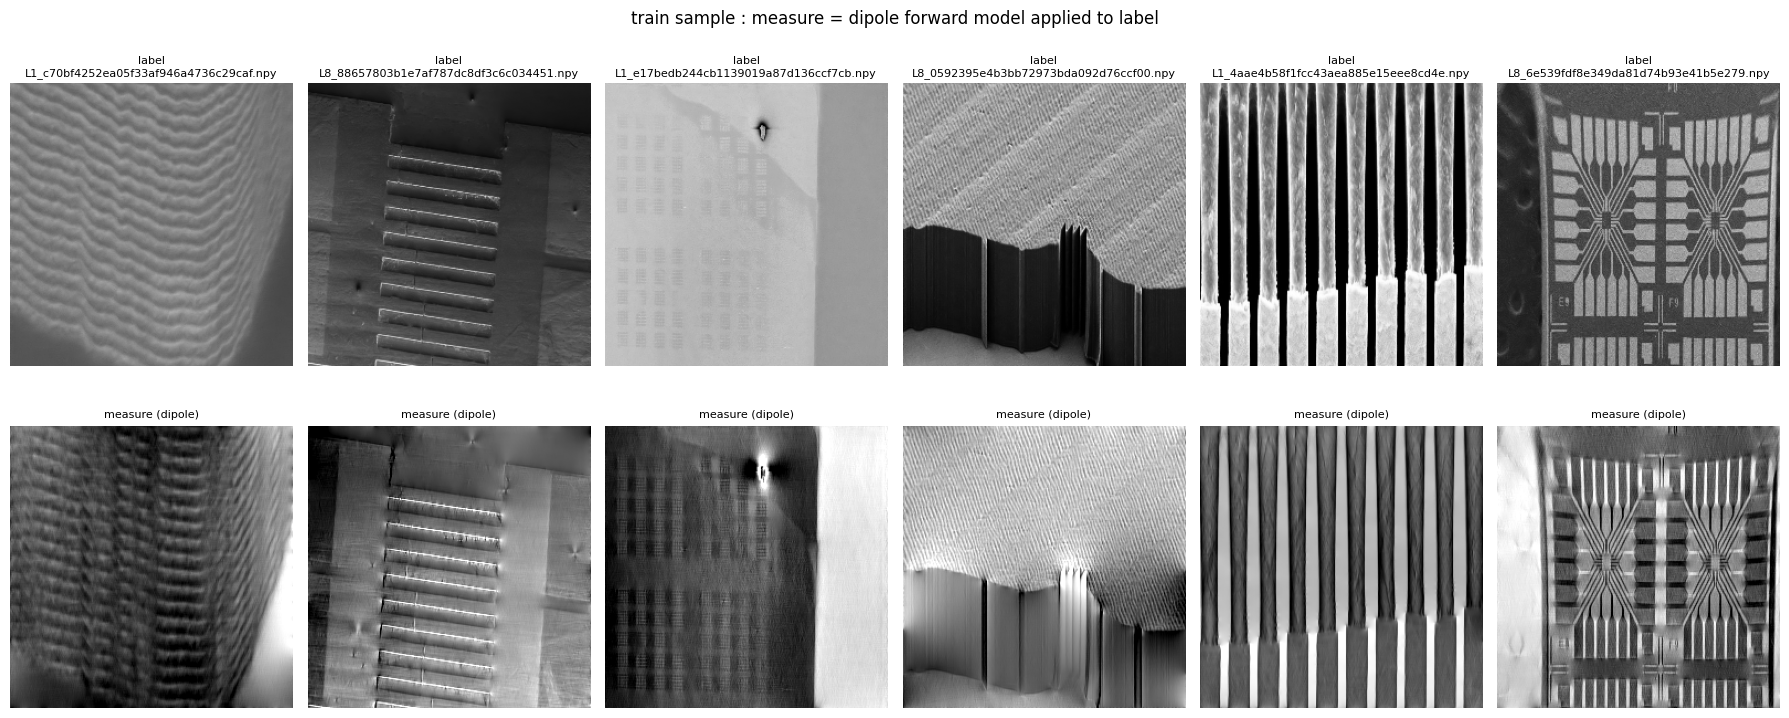

In [15]:
_loader, _, _len = get_data_wrapper_loader(
    file_path=config.train_dataset,
    training_mode=True,
    loader_cfg=LoaderConfig(
        data_type=config.data_type,
        batch=6,
        num_workers=0,
        shuffle=True,
    ),
)
print(f"train dataset length: {_len}")

_label, _measure, _name = next(iter(_loader))
print(f"label   : {tuple(_label.shape)}  range [{_label.min():.3f}, {_label.max():.3f}]")
print(f"measure : {tuple(_measure.shape)}  range [{_measure.min():.3f}, {_measure.max():.3f}]")

n = _label.shape[0]
fig, axes = plt.subplots(2, n, figsize=(3 * n, 7.4))
for i in range(n):
    axes[0, i].imshow(_label[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"label\n{_name[i]}", fontsize=8)
    axes[0, i].axis("off")
    _m = _measure[i, 0].numpy()
    axes[1, i].imshow(_m, cmap="gray", vmin=np.percentile(_m, 1), vmax=np.percentile(_m, 99))
    axes[1, i].set_title("measure (dipole)", fontsize=8)
    axes[1, i].axis("off")
# 그림 안 글자는 Colab 에 한글 폰트가 없어서 ASCII 로만 쓴다
fig.suptitle("train sample : measure = dipole forward model applied to label")
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.subplots_adjust(hspace=0.12)  # 아래 줄 제목이 윗줄 영상과 겹치지 않게
plt.show()

## 9. ModelLoss


In [16]:
def dipole_model_forward(
    pred: Tensor,
    B0_dir: tuple[float, float] = (0.0, 1.0),
) -> Tensor:
    if pred.dim() != 4:
        raise ValueError("Input tensor pred must be 4-dimensional (B, C, H, W)")

    B, C, H, W = pred.shape

    kernel = dipole_kernel(
        matrix_size=(H, W),
        voxel_size=(1.0, 1.0),
        B0_dir=B0_dir,
    ).to(pred.device)
    kernel = kernel.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, H, W)

    pred_k = torch.fft.fftn(pred, dim=(-2, -1))
    pred_dipole = torch.real(torch.fft.ifftn(pred_k * kernel, dim=(-2, -1)))
    return pred_dipole


class ModelLoss(nn.Module):
    def __init__(
        self,
        model_loss_weight: float = 0.5,
        B0_dir: tuple[float, float] = (0.0, 1.0),
    ) -> None:
        super().__init__()
        self.l1 = nn.L1Loss(reduction="none")
        self.l2 = nn.MSELoss(reduction="none")
        self.model_loss_weight = model_loss_weight
        self.B0_dir = B0_dir

    def forward(
        self,
        output: Tensor,
        target: Tensor,
        measure: Tensor,
    ) -> Tensor:
        if output.shape != target.shape:
            raise ValueError("Input and target tensors must have the same shape")

        forward_output = dipole_model_forward(output, B0_dir=self.B0_dir)

        md_loss = self.l1(forward_output, measure)
        l2_loss = self.l2(output, target)

        total_loss = (1 - self.model_loss_weight) * l2_loss + self.model_loss_weight * md_loss
        return total_loss


## 10. train / test core functions


In [17]:
NETWORK = Unet | torch.nn.DataParallel
OPTIM = Adam | AdamW


class ModelType(str, Enum):
    Unet = "unet"

    @classmethod
    def from_string(cls, value: str) -> "ModelType":
        try:
            return cls(value)
        except ValueError as err:
            raise ValueError(f"Invalid ModelType value: {value}. Must be one of {list(cls)} : {err}") from err


def get_network(
    device: torch.device | None,
    model_type: str,
    networkconfig: NetworkConfig,
) -> NETWORK:
    if device is None:
        raise TypeError("device is not to be None")

    if ModelType.from_string(model_type) == ModelType.Unet:
        return Unet(
            in_chans=networkconfig.in_chans,
            out_chans=networkconfig.out_chans,
            chans=networkconfig.chans,
            num_pool_layers=networkconfig.num_pool_layers,
        )
    else:
        raise KeyError("model type not matched")


def get_optim(
    network: NETWORK | None,
    optimizer: str,
) -> OPTIM | None:
    if network is None:
        return None
    if optimizer == "adam":
        return Adam(network.parameters(), betas=(0.9, 0.99))
    elif optimizer == "adamw":
        return AdamW(network.parameters(), betas=(0.9, 0.99), weight_decay=0.0)
    else:
        raise KeyError("optimizer not matched")


def get_loss_func(
    loss_model: str,
) -> Callable:
    if loss_model == "l1":
        return torch.nn.L1Loss(reduction="none")
    elif loss_model == "l2":
        return torch.nn.MSELoss(reduction="none")
    elif loss_model == "model_loss":
        return ModelLoss(model_loss_weight=config.model_loss_weight)
    else:
        raise KeyError("loss func not matched")


def get_learning_rate(
    epoch: int,
    lr: float,
    lr_decay: float,
    lr_tol: int,
) -> float:
    factor = epoch - lr_tol if lr_tol < epoch else 0
    return lr * (lr_decay**factor)


def set_optimizer_lr(
    optimizer: OPTIM | None,
    learning_rate: float,
) -> OPTIM | None:
    if optimizer is None:
        return None
    for param_group in optimizer.param_groups:
        param_group["lr"] = learning_rate
    return optimizer


def log_summary(
    init_time: float,
    state: MetricController,
    log_std: bool = False,
) -> None:
    spend_time = seconds_to_dhms(time.time() - init_time)
    for key in state.state_dict:
        if log_std:
            summary = f"{spend_time} | {key}: {state.mean(key):0.3e} + {state.std(key):0.3e} "
            logger.info(summary)
        else:
            summary = f"{spend_time} | {key}: {state.mean(key):0.3e}"
            logger.info(summary)


def save_checkpoint(
    network: NETWORK,
    run_dir: Path,
    epoch: str | int | None = None,
) -> None:
    if epoch is None:
        epoch = "best"
    os.makedirs(run_dir / "checkpoints", exist_ok=True)
    torch.save(
        {
            "model_state_dict": network.state_dict(),
            "model_config": asdict(networkconfig),
        },
        run_dir / f"checkpoints/checkpoint_{epoch}.ckpt",
    )


def zero_optimizers(
    optim_list: list[OPTIM | None],
) -> None:
    for opt in optim_list:
        if opt is not None:
            opt.zero_grad()


def step_optimizers(
    optim_list: list[OPTIM | None],
) -> None:
    for opt in optim_list:
        if opt is not None:
            opt.step()


def save_result_to_mat(
    test_dir: Path,
    batch_cnt: int,
    tesner_dict: dict[str, Tensor | None],
    img_cnt: int,
) -> None:
    os.makedirs(test_dir, exist_ok=True)
    save_dict = {}

    if batch_cnt == 0:
        logger.warning("batch_cnt is 0, no data to save")
        return

    for i in range(batch_cnt):
        for key, value in tesner_dict.items():
            if value is not None:
                save_dict[key] = value.cpu().detach().numpy()[i, ...]

        idx = img_cnt + i + 1
        savemat(f"{test_dir}/{idx}_res.mat", save_dict)


def train_epoch_unet(
    _data,
    network: NETWORK,
    epoch: int,
    train_state: MetricController,
    loss_func: Callable,
) -> int:
    label: Tensor = _data[DataKey.Label].to(config.device)
    measure: Tensor = _data[DataKey.Measure].to(config.device)

    img_cnt_minibatch = label.shape[0]

    output = network.forward(measure)

    if config.loss_model == "model_loss":
        loss = torch.mean(loss_func(output, label, measure), dim=(1, 2, 3), keepdim=True)
    else:
        loss = torch.mean(loss_func(output, label), dim=(1, 2, 3), keepdim=True)

    torch.mean(loss).backward()
    train_state.add("loss", loss)

    return img_cnt_minibatch


def train_epoch(
    train_loader: DataLoader,
    train_len: int,
    network: NETWORK,
    optim_list: list[OPTIM | None],
    epoch: int,
) -> float:
    train_state = MetricController()
    train_state.reset()
    network.train()
    loss_func = get_loss_func(config.loss_model)  # 배치마다 새로 만들지 않는다

    logging_cnt: int = 1
    img_cnt: int = 0
    batch_pbar = tqdm(train_loader, desc=f"  train ep {epoch + 1}", unit="batch", leave=False)
    for _data in batch_pbar:
        zero_optimizers(optim_list=optim_list)
        if ModelType.from_string(config.model_type) == ModelType.Unet:
            img_cnt_minibatch = train_epoch_unet(
                _data=_data,
                network=network,
                epoch=epoch,
                train_state=train_state,
                loss_func=loss_func,
            )
        else:
            raise KeyError("model type not matched")

        step_optimizers(optim_list=optim_list)
        img_cnt += img_cnt_minibatch
        batch_pbar.set_postfix(loss=f"{train_state.mean('loss'):0.3e}")
        if img_cnt > (train_len / config.logging_density * logging_cnt):
            log_summary(init_time=config.init_time, state=train_state)
            logging_cnt += 1

    log_summary(init_time=config.init_time, state=train_state)
    return float(train_state.mean("loss"))


def test_part_unet(
    _data,
    test_dir: Path,
    model: NETWORK,
    save_val: bool,
    test_state: MetricController,
    img_cnt: int,
) -> int:
    measure = _data[DataKey.Measure].to(config.device)
    label = _data[DataKey.Label].to(config.device)

    batch_cnt = measure.shape[0]

    validate_tensors([measure, label])
    validate_tensor_dimensions([measure, label], 4)

    output = model(measure)

    validate_tensors([output])
    validate_tensor_dimensions([output], 4)

    for idx in range(output.shape[0]):
        test_state.add("psnr", calculate_psnr(output[idx : idx + 1, ...], label[idx : idx + 1, ...]))
        test_state.add("ssim", calculate_ssim(output[idx : idx + 1, ...], label[idx : idx + 1, ...]))

    if save_val:
        save_result_to_mat(
            test_dir=test_dir,
            batch_cnt=batch_cnt,
            tesner_dict={
                "measure": measure,
                "output": output,
                "label": label,
            },
            img_cnt=img_cnt,
        )

    return batch_cnt


def test_part(
    epoch: int,
    data_loader: DataLoader,
    network: NETWORK,
    run_dir: Path,
    save_val: bool,
    desc: str = "valid",
) -> float:
    test_state = MetricController()
    test_state.reset()
    network.eval()
    model = network.module if isinstance(network, torch.nn.DataParallel) else network

    img_cnt: int = 0
    batch_pbar = tqdm(data_loader, desc=f"  {desc}", unit="batch", leave=False)
    for _data in batch_pbar:
        if ModelType.from_string(config.model_type) == ModelType.Unet:
            batch_cnt = test_part_unet(
                _data=_data,
                test_dir=run_dir / f"test/ep_{epoch}",
                model=model,
                save_val=save_val and img_cnt <= config.save_max_idx,
                test_state=test_state,
                img_cnt=img_cnt,
            )
        else:
            raise KeyError("model type not matched")

        img_cnt += batch_cnt
        batch_pbar.set_postfix(psnr=f"{test_state.mean('psnr'):0.2f}")

    log_summary(init_time=config.init_time, state=test_state, log_std=True)

    primary_metric = test_state.mean("psnr")
    return primary_metric

## 11. Validation 결과 시각화


In [18]:
VALID_FIG_MAX: int = 4  # validation 마다 저장할 이미지 수


def save_comparison_figures(
    epoch: int,
    data_loader: DataLoader,
    network: NETWORK,
    run_dir: Path,
    max_images: int = VALID_FIG_MAX,
    tag: str = "valid",
    subdir: str | None = None,
    title_prefix: str | None = None,
) -> Path:
    save_dir = run_dir / (subdir if subdir is not None else f"{tag}_png/ep_{epoch:03d}")
    os.makedirs(save_dir, exist_ok=True)

    network.eval()
    model = network.module if isinstance(network, torch.nn.DataParallel) else network

    saved = 0
    with torch.no_grad():
        for _data in data_loader:
            label = _data[DataKey.Label].to(config.device)
            measure = _data[DataKey.Measure].to(config.device)
            names = _data[DataKey.Name]

            output = model(measure)

            for i in range(output.shape[0]):
                if saved >= max_images:
                    break

                lab_i, mea_i, out_i = label[i : i + 1], measure[i : i + 1], output[i : i + 1]
                psnr_in = calculate_psnr(mea_i, lab_i).item()
                ssim_in = calculate_ssim(mea_i, lab_i).item()
                psnr_out = calculate_psnr(out_i, lab_i).item()
                ssim_out = calculate_ssim(out_i, lab_i).item()

                lab = lab_i.cpu().numpy().squeeze()
                mea = mea_i.cpu().numpy().squeeze()
                out = out_i.cpu().numpy().squeeze()
                err = np.abs(out - lab)

                # label / output / error 는 같은 스케일, measure 는 dipole field 라 스케일이 다르다
                vmax = float(np.percentile(lab, 98) * 1.2)
                err_vmax = float(max(err.max(), 1e-6))

                fig, axes = plt.subplots(1, 4, figsize=(16, 4.6))
                panels = [
                    (lab, "Original (label)", "gray", 0.0, vmax),
                    (
                        mea,
                        f"Measure (dipole)\nPSNR {psnr_in:.2f} dB / SSIM {ssim_in:.4f}",
                        "gray",
                        float(np.percentile(mea, 1)),
                        float(np.percentile(mea, 99)),
                    ),
                    (out, f"Deconvolved (U-Net)\nPSNR {psnr_out:.2f} dB / SSIM {ssim_out:.4f}", "gray", 0.0, vmax),
                    (err, f"Error |output - label|\nmax {err_vmax:.3f}", "magma", 0.0, err_vmax),
                ]
                for ax, (img, title, cmap, lo, hi) in zip(axes, panels):
                    im = ax.imshow(img, cmap=cmap, vmin=lo, vmax=hi)
                    ax.set_title(title, fontsize=10)
                    ax.axis("off")
                fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.02)

                fig.suptitle(
                    f"{title_prefix if title_prefix is not None else f'epoch {epoch}'}"
                    f" | {names[i]}"
                    f" | PSNR {psnr_in:.2f} -> {psnr_out:.2f} dB",
                    fontsize=11,
                )
                fig.tight_layout(rect=(0, 0, 1, 0.90))
                fig.savefig(save_dir / f"{Path(names[i]).stem}.png", dpi=150, bbox_inches="tight")
                plt.close(fig)
                saved += 1

            if saved >= max_images:
                break

    logger.info(f"Saved {saved} comparison figures to {save_dir}")
    return save_dir

## 12. Trainer


In [19]:
class Trainer:
    run_dir: Path
    network: NETWORK
    train_loader: DataLoader
    train_len: int
    valid_loader: DataLoader
    optims: list[OPTIM | None]

    def __init__(
        self,
    ) -> None:
        config.init_time = time.time()
        config.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(config.device)

        # dir setting
        self.run_dir = config.run_dir / f"{call_next_id(config.run_dir):05d}_train"
        logger_add_handler(logger, f"{self.run_dir/'log.log'}", config.log_lv)
        logger.info(separator())
        logger.info(f"Run dir: {self.run_dir}")
        os.makedirs(self.run_dir, exist_ok=True)

        # log config
        logger.info(separator())
        logger.info("General Config")
        config_dict = asdict(config)
        for k in config_dict:
            logger.info(f"{k}:{config_dict[k]}")
        logger.info(separator())
        logger.info("Model Config")
        config_dict = asdict(networkconfig)
        for k in config_dict:
            logger.info(f"{k}:{config_dict[k]}")

    def __call__(
        self,
    ) -> None:
        self._set_data()
        self._set_network()
        self._train()

    @error_wrap
    def _set_data(
        self,
    ) -> None:
        logger.info(separator())
        train_loader_cfg = LoaderConfig(
            data_type=config.data_type,
            batch=config.train_batch,
            num_workers=config.num_workers,
            shuffle=True,
        )

        valid_loader_cfg = LoaderConfig(
            data_type=config.data_type,
            batch=config.valid_batch,
            num_workers=config.num_workers,
            shuffle=False,
        )

        self.train_loader, _, self.train_len = get_data_wrapper_loader(
            file_path=config.train_dataset,
            training_mode=True,
            loader_cfg=train_loader_cfg,
        )
        logger.info(f"Train dataset length : {self.train_len}")

        self.valid_loader, _, valid_len = get_data_wrapper_loader(
            file_path=config.valid_dataset,
            training_mode=False,
            loader_cfg=valid_loader_cfg,
        )
        logger.info(f"Valid dataset length : {valid_len}")

    @error_wrap
    def _set_network(
        self,
    ) -> None:
        self.network = get_network(
            device=config.device,
            model_type=config.model_type,
            networkconfig=networkconfig,
        )

        self.optims = [
            get_optim(
                network=self.network,
                optimizer=config.optimizer,
            ),
        ]

        if config.parallel:
            self.network = torch.nn.DataParallel(self.network).to(config.device)
        else:
            self.network = self.network.to(config.device)

    @error_wrap
    def _train(
        self,
    ) -> None:
        logger.info(separator())
        logger.info("Train start")

        best_metric: float = 0
        primary_metric: float | None = None
        postfix: dict[str, str] = {}
        epoch_pbar = tqdm(range(config.train_epoch), desc="Epoch", unit="epoch", leave=True)

        for epoch in epoch_pbar:
            lr_epoch = get_learning_rate(
                epoch=epoch,
                lr=config.lr,
                lr_decay=config.lr_decay,
                lr_tol=config.lr_tol,
            )
            postfix["lr"] = f"{lr_epoch:0.3e}"
            epoch_pbar.set_postfix(postfix)
            tqdm.write(f"Epoch {epoch + 1}/{config.train_epoch} | lr={lr_epoch:0.3e}")

            optims = [set_optimizer_lr(optimizer=optim, learning_rate=lr_epoch) for optim in self.optims]

            train_loss = train_epoch(
                train_loader=self.train_loader,
                train_len=self.train_len,
                network=self.network,
                optim_list=optims,
                epoch=epoch,
            )
            postfix["loss"] = f"{train_loss:0.3e}"
            epoch_pbar.set_postfix(postfix)

            save_checkpoint(
                network=self.network,
                run_dir=self.run_dir,
                epoch=epoch,
            )

            if epoch < config.valid_tol:
                continue

            # validation 을 돌린 epoch 에서만 best 를 갱신한다
            # (그렇지 않으면 직전 epoch 의 metric 으로 검증되지 않은 가중치를 best 로 덮어쓴다)
            if epoch % config.valid_interval != 0:
                continue

            primary_metric = self._valid(epoch)
            if primary_metric is None:
                logger.warning("Validation 실패 -> best checkpoint 갱신을 건너뛴다")
                continue

            postfix["val_psnr"] = f"{primary_metric:0.2f}"
            epoch_pbar.set_postfix(postfix)

            # best 기준은 validation PSNR (test_part 가 psnr 평균을 반환한다)
            if primary_metric > best_metric:
                best_metric = primary_metric
                logger.success(f"Best model renew (valid psnr {best_metric:0.4f})")
                save_checkpoint(
                    network=self.network,
                    run_dir=self.run_dir,
                )

    @error_wrap
    def _valid(
        self,
        epoch: int,
    ) -> float:
        logger.info("Valid")
        with torch.no_grad():
            primary_metric = test_part(
                epoch=epoch,
                data_loader=self.valid_loader,
                network=self.network,
                run_dir=self.run_dir,
                save_val=False,
                desc=f"valid ep {epoch + 1}",
            )

        try:
            save_comparison_figures(
                epoch=epoch,
                data_loader=self.valid_loader,
                network=self.network,
                run_dir=self.run_dir,
            )
        except Exception as err:
            logger.warning(f"Failed to save validation figures: {err}")

        return primary_metric

### 학습 실행


In [21]:
trainer = Trainer()
trainer()

TRAIN_RUN_DIR = trainer.run_dir
print("train run dir:", TRAIN_RUN_DIR)

cuda
2026-09-01 05:03:30 [INFO] ####################################################################################################
2026-09-01 05:03:30 [INFO] Run dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train
2026-09-01 05:03:34 [INFO] ####################################################################################################
2026-09-01 05:03:34 [INFO] General Config
2026-09-01 05:03:34 [INFO] train_dataset:['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/train']
2026-09-01 05:03:34 [INFO] valid_dataset:['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/val']
2026-09-01 05:03:34 [INFO] test_dataset:['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_label']
2026-09-01 05:03:34 [INFO] data_type:*.npy
2026-09-01 05:03:34 [INFO] test_measure_dir:None
2026-09-01 05:03:34 [INFO] measure_noise:False
2026-09-01 05:03:34 [INFO] measure_noise_type:gaussian
2026-09-01 05:03:34 [

Epoch:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1/30 | lr=1.000e-04


  train ep 1:   0%|          | 0/114 [00:00<?, ?batch/s]

2026-09-01 05:04:11 [INFO] 00h 01m 30s | loss: 1.545e-01
2026-09-01 05:04:40 [INFO] 00h 01m 58s | loss: 1.093e-01
2026-09-01 05:05:01 [INFO] 00h 02m 20s | loss: 8.709e-02
2026-09-01 05:05:33 [INFO] 00h 02m 51s | loss: 7.267e-02
2026-09-01 05:05:33 [INFO] Valid


...

2026-09-01 05:14:41 [INFO] 00h 11m 59s | psnr: 2.574e+01 + 3.830e+00 
2026-09-01 05:14:41 [INFO] 00h 11m 59s | ssim: 8.865e-01 + 6.610e-02 
2026-09-01 05:14:45 [INFO] Saved 4 comparison figures to /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train/valid_png/ep_028
Epoch 30/30 | lr=2.789e-06


  train ep 30:   0%|          | 0/114 [00:00<?, ?batch/s]

2026-09-01 05:14:49 [INFO] 00h 12m 07s | loss: 3.040e-03
2026-09-01 05:14:52 [INFO] 00h 12m 10s | loss: 3.049e-03
2026-09-01 05:14:55 [INFO] 00h 12m 13s | loss: 3.013e-03
2026-09-01 05:14:58 [INFO] 00h 12m 17s | loss: 3.020e-03
2026-09-01 05:14:58 [INFO] Valid


  valid ep 30:   0%|          | 0/100 [00:00<?, ?batch/s]

2026-09-01 05:14:59 [INFO] 00h 12m 17s | psnr: 2.578e+01 + 3.828e+00 
2026-09-01 05:14:59 [INFO] 00h 12m 17s | ssim: 8.867e-01 + 6.601e-02 
2026-09-01 05:15:03 [INFO] Saved 4 comparison figures to /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train/valid_png/ep_029
2026-09-01 05:15:03 [SUCCESS] Best model renew (valid psnr 25.7813)
train run dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train


## 학습 결과

best checkpoint 는 **validation PSNR** 이 가장 높았던 시점의 가중치이고,
`{run_dir}/checkpoints/checkpoint_best.ckpt` 에 저장된다.


In [22]:
best_ckpt = TRAIN_RUN_DIR / "checkpoints/checkpoint_best.ckpt"
print("best checkpoint:", best_ckpt, "| exists:", best_ckpt.exists())

valid_pngs = sorted((TRAIN_RUN_DIR / "valid_png").rglob("*.png"))
print(f"validation figures: {len(valid_pngs)} png in {TRAIN_RUN_DIR / 'valid_png'}")
for p in valid_pngs[-4:]:
    print(" ", p)

best checkpoint: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train/checkpoints/checkpoint_best.ckpt | exists: True
validation figures: 120 png in /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train/valid_png
  /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train/valid_png/ep_029/L1_04e524d382fc4f1aecdf6bbf39bd5b0f.png
  /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train/valid_png/ep_029/L1_0aceacb0b3bbb83e38dd3f314b5b61b8.png
  /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train/valid_png/ep_029/L1_0b01fddd63d7c84949f7439279d7bd21.png
  /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train/valid_png/ep_029/L1_0b8e81c4fb1673f558be432fc1e3360f.png


## 13. 학습이 끝난 뒤 테스트 (best checkpoint)

학습 중에는 validation 만 돌고, test 는 여기서 **best checkpoint 로 한 번만** 돌린다.
(best 는 validation PSNR 기준으로 고른 가중치다.)

| | 경로 |
|---|---|
| label | `config.test_dataset` = `dataset/test_label` |
| measure | `config.test_measure_dir` = `dataset/test_deconv_only` |

결과물: `{run_dir}/test_metrics.json` (영상별 지표), `{run_dir}/test_png/*.png` (비교 이미지)


In [23]:
TEST_MAX_FIG: int = 8  # 저장할 비교 이미지 수

# 학습 셀을 방금 돌렸다면 그 run_dir 을 그대로 쓴다.
# 세션을 새로 열었다면 아래 줄을 직접 지정할 것: TEST_RUN_DIR = RUN_DIR / "00000_train"
TEST_RUN_DIR = globals().get("TRAIN_RUN_DIR")
if TEST_RUN_DIR is None:
    raise RuntimeError("학습 셀을 먼저 실행하거나 TEST_RUN_DIR 을 직접 지정할 것 (예: RUN_DIR / '00000_train')")

BEST_CKPT = TEST_RUN_DIR / "checkpoints/checkpoint_best.ckpt"

# 학습 셀 없이 이 셀부터 실행하는 경우를 대비
if config.device is None:
    config.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if config.init_time == 0.0:
    config.init_time = time.time()


def load_checkpoint_network(
    ckpt_path: Path,
    device: torch.device,
) -> Unet:
    checkpoint_data = torch.load(ckpt_path, map_location="cpu", weights_only=True)

    if not (("model_state_dict" in checkpoint_data) and ("model_config" in checkpoint_data)):
        raise KeyError(f"Invalid checkpoint: {ckpt_path}")

    modelconfig = NetworkConfig(**checkpoint_data["model_config"])
    network = Unet(
        in_chans=modelconfig.in_chans,
        out_chans=modelconfig.out_chans,
        chans=modelconfig.chans,
        num_pool_layers=modelconfig.num_pool_layers,
    )

    # DataParallel 로 저장된 경우 key 앞의 "module." 를 떼어낸다
    _state_dict = {k.replace("module.", ""): v for k, v in checkpoint_data["model_state_dict"].items()}
    network.load_state_dict(_state_dict, strict=True)

    logger.info(f"Loaded checkpoint: {ckpt_path}")
    for k, v in asdict(modelconfig).items():
        logger.info(f"{k}:{v}")

    return network.to(device).eval()


test_network = load_checkpoint_network(BEST_CKPT, config.device)

test_loader, _, test_len = get_data_wrapper_loader(
    file_path=config.test_dataset,
    training_mode=False,
    loader_cfg=LoaderConfig(
        data_type=config.data_type,
        batch=config.valid_batch,
        num_workers=config.num_workers,
        shuffle=False,
        measure_path=config.test_measure_dir,
    ),
)
print(f"checkpoint : {BEST_CKPT}")
print(f"label      : {config.test_dataset[0]}")
print(f"measure    : {config.test_measure_dir or 'on-the-fly (ForwardSimulator)'}")
print(f"test images: {test_len}")

2026-09-01 05:15:11 [INFO] Loaded checkpoint: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train/checkpoints/checkpoint_best.ckpt
2026-09-01 05:15:11 [INFO] in_chans:1
2026-09-01 05:15:11 [INFO] out_chans:1
2026-09-01 05:15:11 [INFO] chans:16
2026-09-01 05:15:11 [INFO] num_pool_layers:4
checkpoint : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train/checkpoints/checkpoint_best.ckpt
label      : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_label
measure    : on-the-fly (ForwardSimulator)
test images: 100


In [24]:
test_state = MetricController()
test_state.reset()
rows: list[dict] = []

with torch.no_grad():
    for _data in tqdm(test_loader, desc="test", unit="batch"):
        label = _data[DataKey.Label].to(config.device)
        measure = _data[DataKey.Measure].to(config.device)
        names = _data[DataKey.Name]

        output = test_network(measure)

        for i in range(output.shape[0]):
            out_i, lab_i, mea_i = output[i : i + 1], label[i : i + 1], measure[i : i + 1]
            psnr_out = calculate_psnr(out_i, lab_i)
            ssim_out = calculate_ssim(out_i, lab_i)
            test_state.add("psnr", psnr_out)
            test_state.add("ssim", ssim_out)
            rows.append(
                {
                    "file": names[i],
                    "psnr": psnr_out.item(),
                    "ssim": ssim_out.item(),
                    "psnr_in": calculate_psnr(mea_i, lab_i).item(),
                    "ssim_in": calculate_ssim(mea_i, lab_i).item(),
                }
            )

log_summary(init_time=config.init_time, state=test_state, log_std=True)

with open(TEST_RUN_DIR / "test_metrics.json", "w") as f:
    json.dump(rows, f, indent=2)

print()
print(f"{'':<18}{'n':>5}{'PSNR in':>10}{'PSNR out':>10}{'SSIM in':>10}{'SSIM out':>10}")
print("-" * 63)
print(
    f"{'test (best ckpt)':<18}{len(rows):>5}"
    f"{np.mean([r['psnr_in'] for r in rows]):>10.3f}"
    f"{np.mean([r['psnr'] for r in rows]):>10.3f}"
    f"{np.mean([r['ssim_in'] for r in rows]):>10.4f}"
    f"{np.mean([r['ssim'] for r in rows]):>10.4f}"
)
print(
    f"{'std':<18}{'':>5}"
    f"{np.std([r['psnr_in'] for r in rows], ddof=1):>10.3f}"
    f"{np.std([r['psnr'] for r in rows], ddof=1):>10.3f}"
    f"{np.std([r['ssim_in'] for r in rows], ddof=1):>10.4f}"
    f"{np.std([r['ssim'] for r in rows], ddof=1):>10.4f}"
)

test_png_dir = save_comparison_figures(
    epoch=0,
    data_loader=test_loader,
    network=test_network,
    run_dir=TEST_RUN_DIR,
    max_images=TEST_MAX_FIG,
    subdir="test_png",
    title_prefix="test (best ckpt)",
)
print(f"\nmetrics : {TEST_RUN_DIR / 'test_metrics.json'}")
print(f"figures : {test_png_dir}")

test:   0%|          | 0/100 [00:00<?, ?batch/s]

2026-09-01 05:15:59 [INFO] 00h 13m 18s | psnr: 2.586e+01 + 3.802e+00 
2026-09-01 05:15:59 [INFO] 00h 13m 18s | ssim: 8.813e-01 + 6.623e-02 

                      n   PSNR in  PSNR out   SSIM in  SSIM out
---------------------------------------------------------------
test (best ckpt)    100     7.892    25.860    0.0318    0.8813
std                         1.949     3.802    0.2124    0.0662
2026-09-01 05:16:07 [INFO] Saved 8 comparison figures to /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train/test_png

metrics : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train/test_metrics.json
figures : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train/test_png


### 저장된 test 결과 이미지


In [25]:
# PIL.Image 를 가리지 않도록 별칭으로 가져온다
from IPython.display import Image as IPyImage
from IPython.display import display

for p in sorted(test_png_dir.glob("*.png"))[:3]:
    print(p.name)
    display(IPyImage(filename=str(p)))

Output hidden; open in https://colab.research.google.com to view.

## 14. Conventional method 비교 (TKD / Wiener filter)

Deconvolution 에서는 **dipole kernel 을 직접 뒤집는 방법**들과 비교한다.

| 방법 | 설명 |
|---|---|
| U-Net  | 학습된 best checkpoint |
| TKD (truncated kernel division)  | `1/D` 를 `+-clip` 으로 잘라서 magic angle 근처를 막는다 |
| Wiener filter | `1/D * D^2/(D^2 + K)` 로 부드럽게 감쇠 |
| Tikhonov | `D / (D^2 + lambda)`. **Wiener 와 대수적으로 동일한 필터** (`K == lambda` 면 결과가 같다) |

세 방법 다 학습이 필요 없고, forward model(`dipole_kernel`)을 안다는 가정만 쓴다.

> `measure` 에 노이즈가 없으면 (`config.measure_noise = False`) 이 역필터들이 거의 완벽하게 복원하므로
> U-Net 과의 비교가 의미를 잃는다. 비교를 하려면 `config.measure_noise = True` 로 두고
> `measure_noise_sigma` 를 설정해 노이즈가 있는 forward model 로 학습/평가할 것.


In [26]:
def tkd(
    img: Tensor,
    clip: float = 5.0,
    B0_dir: tuple[float, float] = (0.0, 1.0),
) -> Tensor:
    """Truncated k-space division (TKD).

    k-space 에서 |1/kernel| > clip 인 영역을 truncate 한다.
    """
    kernel = dipole_kernel(
        matrix_size=tuple(img.shape[-2:]),
        voxel_size=(1.0, 1.0),
        B0_dir=B0_dir,
    ).to(img.device)

    kernel_inv = torch.clip(1 / kernel, min=-clip, max=clip)
    img_k = torch.fft.fftn(img, dim=(-2, -1))
    return torch.fft.ifftn(img_k * kernel_inv, dim=(-2, -1)).real


def wiener_deconv(
    img: Tensor,
    K: float = 1e-2,
    B0_dir: tuple[float, float] = (0.0, 1.0),
) -> Tensor:
    """Wiener filter: (1/H) * |H|^2 / (|H|^2 + K)."""
    kernel = dipole_kernel(
        matrix_size=tuple(img.shape[-2:]),
        voxel_size=(1.0, 1.0),
        B0_dir=B0_dir,
    ).to(img.device)

    h2 = kernel**2
    safe_den = torch.where(kernel.abs() < 1e-12, torch.full_like(kernel, 1e-12), kernel)
    w = (1.0 / safe_den) * (h2 / (h2 + K))

    img_k = torch.fft.fftn(img, dim=(-2, -1))
    return torch.fft.ifftn(img_k * w, dim=(-2, -1)).real


def tikhonov_deconv(
    img: Tensor,
    reg_lambda: float = 1e-2,
    B0_dir: tuple[float, float] = (0.0, 1.0),
) -> Tensor:
    """Tikhonov (L2 norm) Regularization Deconvolution (Day 2 Slide 20-22).

    argmin ||H x - y||_2^2 + lambda ||x||_2^2
    -> x = (H^H H + lambda I)^(-1) H^H y = [ H / (H^2 + lambda) ] * y

    주의: 이 식은 Wiener filter (1/H)*|H|^2/(|H|^2+K) 와 **대수적으로 동일**하다
    (conj(H)/(|H|^2+K)). 따라서 K == lambda 면 두 방법의 결과가 완전히 같다.
    구분되는 것은 K 의 해석(Wiener 는 noise/signal power ratio)뿐이다.
    아래 _self_check 에서 이 항등식을 검증한다.
    """
    kernel = dipole_kernel(
        matrix_size=tuple(img.shape[-2:]),
        voxel_size=(1.0, 1.0),
        B0_dir=B0_dir,
    ).to(img.device)

    tikhonov_inv = kernel / (kernel**2 + reg_lambda)
    img_k = torch.fft.fftn(img, dim=(-2, -1))
    return torch.fft.ifftn(img_k * tikhonov_inv, dim=(-2, -1)).real


def _self_check() -> None:
    """기존 구현 및 배치 일치 검증."""
    x = torch.rand(3, 1, 32, 32)
    tkd_res = tkd(x, clip=5.0)
    wie_res = wiener_deconv(x, K=1e-2)
    tik_res = tikhonov_deconv(x, reg_lambda=1e-2)
    assert tkd_res.shape == x.shape, "tkd shape mismatch"
    assert wie_res.shape == x.shape, "wiener shape mismatch"
    assert tik_res.shape == x.shape, "tikhonov shape mismatch"

    # 실수 kernel 이므로 Wiener(K) 와 Tikhonov(lambda=K) 는 같은 필터다
    same = tikhonov_deconv(x, reg_lambda=1e-2)
    assert torch.allclose(wie_res, same, atol=1e-5), "wiener != tikhonov (수식 확인 필요)"
    print("Conventional methods self-check ok (TKD, Wiener, Tikhonov)")
    print("note: Wiener(K) == Tikhonov(lambda=K) 임을 확인 (동일 필터, K 해석만 다름)")


_self_check()


Conventional methods self-check ok (TKD, Wiener, Tikhonov)
note: Wiener(K) == Tikhonov(lambda=K) 임을 확인 (동일 필터, K 해석만 다름)


In [27]:
TKD_CLIP: float = 5.0
WIENER_K: float = 1e-4  # 표/그림의 기본값
TIKHONOV_LAMBDA: float = 1e-3  # Wiener(K) 와 동일한 필터이므로 K 와 다른 값으로 둔다
WIENER_K_SWEEP: list[float] = [1e-1, 1e-2, 1e-3, 1e-4]

METHODS: list[str] = ["measure", "unet", "tkd", "wiener", "tikhonov"]
METHOD_LABEL: dict[str, str] = {
    "measure": "Measure (input)",
    "unet": "U-Net (best)",
    "tkd": f"TKD (clip {TKD_CLIP:g})",
    "wiener": f"Wiener (K={WIENER_K:g})",
    "tikhonov": f"Tikhonov (λ={TIKHONOV_LAMBDA:g})",
}

GRID_MAX: int = 3  # 아래 그림에 쓸 영상 수

baseline_rows: list[dict] = []
sweep_rows: list[dict] = []
samples: list[dict] = []

test_network.eval()
with torch.no_grad():
    for _data in tqdm(test_loader, desc="conventional", unit="batch"):
        label = _data[DataKey.Label].to(config.device)
        measure = _data[DataKey.Measure].to(config.device)
        names = _data[DataKey.Name]

        outputs = {
            "measure": measure,
            "unet": test_network(measure),
            "tkd": tkd(measure, clip=TKD_CLIP),
            "wiener": wiener_deconv(measure, K=WIENER_K),
            "tikhonov": tikhonov_deconv(measure, reg_lambda=TIKHONOV_LAMBDA),
        }
        sweep = {K: wiener_deconv(measure, K=K) for K in WIENER_K_SWEEP}

        for i in range(label.shape[0]):
            lab_i = label[i : i + 1]
            row = {"file": names[i]}
            for key in METHODS:
                pred_i = outputs[key][i : i + 1]
                row[f"psnr_{key}"] = calculate_psnr(pred_i, lab_i).item()
                row[f"ssim_{key}"] = calculate_ssim(pred_i, lab_i).item()
            baseline_rows.append(row)

            sweep_row = {"file": names[i]}
            for K in WIENER_K_SWEEP:
                pred_i = sweep[K][i : i + 1]
                sweep_row[f"psnr_{K:g}"] = calculate_psnr(pred_i, lab_i).item()
                sweep_row[f"ssim_{K:g}"] = calculate_ssim(pred_i, lab_i).item()
            sweep_rows.append(sweep_row)

            if len(samples) < GRID_MAX:
                sample = {"name": names[i], "metrics": row, "label": lab_i.cpu().numpy().squeeze()}
                for key in METHODS:
                    sample[key] = outputs[key][i : i + 1].cpu().numpy().squeeze()
                samples.append(sample)

print()
print(f"{'method':<24}{'n':>5}{'PSNR':>10}{'PSNR std':>10}{'SSIM':>10}{'SSIM std':>10}")
print("-" * 69)
for key in METHODS:
    psnr = [r[f"psnr_{key}"] for r in baseline_rows]
    ssim = [r[f"ssim_{key}"] for r in baseline_rows]
    print(
        f"{METHOD_LABEL[key]:<24}{len(baseline_rows):>5}"
        f"{np.mean(psnr):>10.3f}{np.std(psnr, ddof=1):>10.3f}"
        f"{np.mean(ssim):>10.4f}{np.std(ssim, ddof=1):>10.4f}"
    )

print()
print("[Wiener K sweep]")
print(f"{'K':<20}{'n':>5}{'PSNR':>10}{'SSIM':>10}")
print("-" * 45)
for K in WIENER_K_SWEEP:
    psnr = [r[f"psnr_{K:g}"] for r in sweep_rows]
    ssim = [r[f"ssim_{K:g}"] for r in sweep_rows]
    print(f"{f'K = {K:g}':<20}{len(sweep_rows):>5}{np.mean(psnr):>10.3f}{np.mean(ssim):>10.4f}")

with open(TEST_RUN_DIR / "baseline_metrics.json", "w") as f:
    json.dump({"methods": baseline_rows, "wiener_k_sweep": sweep_rows}, f, indent=2)
print(f"\nmetrics : {TEST_RUN_DIR / 'baseline_metrics.json'}")


conventional:   0%|          | 0/100 [00:00<?, ?batch/s]


method                      n      PSNR  PSNR std      SSIM  SSIM std
---------------------------------------------------------------------
Measure (input)           100     7.892     1.949    0.0318    0.2124
U-Net (best)              100    25.860     3.802    0.8813    0.0662
TKD (clip 5)              100    31.187     5.597    0.9337    0.0575
Wiener (K=0.0001)         100    42.251     5.667    0.9881    0.0223
Tikhonov (λ=0.001)        100    35.377     4.726    0.9703    0.0361

[Wiener K sweep]
K                       n      PSNR      SSIM
---------------------------------------------
K = 0.1               100    11.896    0.6693
K = 0.01              100    24.847    0.9273
K = 0.001             100    35.377    0.9703
K = 0.0001            100    42.251    0.9881

metrics : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution/00002_train/baseline_metrics.json


### 결과 비교 그림

행 = test 영상, 열 = **Measure / U-Net / error / TKD / error / Wiener / error**.

- error map 은 `magma` (어두울수록 오차 0).


In [28]:
ERROR_CMAP = "magma"
GRID_COLS = ["unet", "tkd", "wiener", "tikhonov"]

if not samples:
    raise RuntimeError("samples 가 비어 있다. 앞의 conventional 비교 셀을 먼저 실행할 것")

# 각 방법당 2열 (복원 영상 + 상대 오차율 맵 (%))
n_col = 1 + 2 * len(GRID_COLS)
fig, axes = plt.subplots(len(samples), n_col, figsize=(3.2 * n_col, 4.2 * len(samples)))
axes = np.asarray(axes).reshape(len(samples), n_col)

for r, sample in enumerate(samples):
    lab = sample["label"]
    metrics = sample["metrics"]

    vmax = float(np.percentile(lab, 98) * 1.2)
    # 과제 요구사항: 상대 오차율(%) = |output - GT| / (GT + eps) * 100 (%)
    eps = 1e-4
    rel_errors = {
        key: np.abs(sample[key] - lab) / (np.abs(lab) + eps) * 100.0
        for key in GRID_COLS
    }
    # 극단값 클리핑 (99 percentile)
    err_vmax = float(max(np.percentile(np.stack(list(rel_errors.values())), 99), 5.0))

    # 0열: 입력(measure). dipole field 라 스케일을 따로 잡는다
    mea = sample["measure"]
    ax = axes[r, 0]
    ax.imshow(mea, cmap="gray", vmin=float(np.percentile(mea, 1)), vmax=float(np.percentile(mea, 99)))
    ax.set_title(f"{METHOD_LABEL['measure']}\nPSNR {metrics['psnr_measure']:.2f} dB", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_ylabel(sample["name"], fontsize=10)

    for c, key in enumerate(GRID_COLS):
        ax = axes[r, 1 + 2 * c]
        ax.imshow(sample[key], cmap="gray", vmin=0.0, vmax=vmax)
        ax.set_title(
            f"{METHOD_LABEL[key]}\nPSNR {metrics[f'psnr_{key}']:.2f} dB / SSIM {metrics[f'ssim_{key}']:.4f}",
            fontsize=9,
        )
        ax.axis("off")

        ax_err = axes[r, 2 + 2 * c]
        im = ax_err.imshow(rel_errors[key], cmap=ERROR_CMAP, vmin=0.0, vmax=err_vmax)
        ax_err.set_title(f"Rel Error (%)\nmedian {np.median(rel_errors[key]):.1f}%", fontsize=9)
        ax_err.axis("off")

    fig.colorbar(im, ax=axes[r, -1], fraction=0.046, pad=0.02, label="Rel Error (%)")

fig.suptitle(
    f"U-Net vs TKD / Wiener / Tikhonov  |  test set: {Path(config.test_dataset[0]).name}"
    f"  |  relative error map shared scale per row",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.subplots_adjust(hspace=0.22)

grid_path = TEST_RUN_DIR / "baseline_grid.png"
fig.savefig(grid_path, dpi=150, bbox_inches="tight")
print(f"saved: {grid_path}")
plt.show()


Output hidden; open in https://colab.research.google.com to view.